# Trabajo Práctico Integrador — Entrega 2
## Ciencia de Datos 2026 | UTN FRC | 5K4 | Grupo 15

---

### Descripción de la entrega

Este notebook implementa el pipeline **ETL (Extract, Transform, Load)** completo sobre el dataset PAMAP2, correspondiente a la **Entrega 2** del TPI. Incluye:

- Carga y unificación de los 9 archivos fuente (.dat)
- Downsampling 100 Hz → 10 Hz
- Eliminación de columnas inválidas (orientación IMU)
- Exclusión de períodos transitorios (activityID = 0)
- Tratamiento de valores faltantes en heart\_rate
- Verificación y guardado del dataset limpio

---

### Integrantes — Grupo 15

| Rol            | Nombre                      | Legajo |
|----------------|----------------------------|--------|
| Product Owner  | Franco Recalde             | 94661  |
| Scrum Master   | Emilio Sadir               | 96622  |
| dev            | Rodríguez, Joaquín Ignacio | 85406  |
| dev            | Noto, Claudia Carina       | 95215  |
| dev            | Monteros, Leandro Ignacio  | 90258  |
| dev            | Ferraro, Ayelen            | 99149  |
| dev            | Chiaro, Tiziano            | 90043  |
| dev            | Bailey, Julián Eduardo     | 96032  |

---

### Dataset

**PAMAP2 Physical Activity Monitoring Dataset**  
Fuente: [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/231/pamap2+physical+activity+monitoring)  
Licencia: CC BY 4.0  
Autores: A. Reiss y D. Stricker (DFKI, Alemania)

# Paso 0.0: Importación, configuración y unificación de datos
Este segmento incluye:
- Importación de librerías
- Configuración del entorno
- Definición de columnas
- Carga y unificación de archivos fuente
- Downsampling
- Visualización del impacto de estas operaciones




### Paso 0.1:Empezando con la importación de librerías:

In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

print('Librerias cargadas correctamente.')

Librerias cargadas correctamente.


### Paso 0.2: Configuración del entorno

La notebook detecta automáticamente si se ejecuta en **Google Colab** o localmente.
En Colab se monta Google Drive y se asume que la carpeta del proyecto está en `MyDrive/TP_CD/`.
Ajustar `BASE_PATH` si la ubicación en Drive es diferente.

In [12]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/TP_CD')
else:
    BASE_PATH = Path('..').resolve()

DATA_PROTOCOL = BASE_PATH / 'PAMAP2_Dataset' / 'Protocol'
DATA_OPTIONAL = BASE_PATH / 'PAMAP2_Dataset' / 'Optional'
OUTPUT_PATH   = BASE_PATH / 'data' / 'processed'
FIGURES_PATH  = BASE_PATH / 'reports' / 'entrega_2' / 'figures'

OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

env_name = 'Google Colab' if IN_COLAB else 'Local'
print(f'Entorno:   {env_name}')
print(f'Datos en:  {DATA_PROTOCOL}')
print(f'Output en: {OUTPUT_PATH}')

Entorno:   Local
Datos en:  D:\FACU\5to\Ciencia de datos\pamap2+physical+activity+monitoring\TP_CD\PAMAP2_Dataset\Protocol
Output en: D:\FACU\5to\Ciencia de datos\pamap2+physical+activity+monitoring\TP_CD\data\processed


### Paso 0.3: Definición de columnas

El dataset PAMAP2 no incluye header en sus archivos `.dat`. Las **54 columnas** se asignan
manualmente según la documentación oficial (readme.pdf, UCI). Se identifican las
**12 columnas de orientación** (4 por IMU × 3 IMUs: hand, chest, ankle) que serán
eliminadas en el Paso 3 por ser inválidas según la documentación oficial.

In [13]:
RAW_COLUMNAS = [
    'tiempo', 'actividad_id', 'frecuencia_cardiaca',
    # IMU mano — 17 columnas
    'mano_temperatura',
    'mano_acel1_x', 'mano_acel1_y', 'mano_acel1_z',
    'mano_acel2_x', 'mano_acel2_y', 'mano_acel2_z',
    'mano_giro_x', 'mano_giro_y', 'mano_giro_z',
    'mano_magneto_x',  'mano_magneto_y',  'mano_magneto_z',
    'mano_orientacion_1', 'mano_orientacion_2', 'mano_orientacion_3', 'mano_orientacion_4',
    # IMU pecho — 17 columnas
    'pecho_temperatura',
    'pecho_acel1_x', 'pecho_acel1_y', 'pecho_acel1_z',
    'pecho_acel2_x', 'pecho_acel2_y', 'pecho_acel2_z',
    'pecho_giro_x', 'pecho_giro_y', 'pecho_giro_z',
    'pecho_magneto_x',  'pecho_magneto_y',  'pecho_magneto_z',
    'pecho_orientacion_1', 'pecho_orientacion_2', 'pecho_orientacion_3', 'pecho_orientacion_4',
    # IMU tobillo — 17 columnas
    'tobillo_temperatura',
    'tobillo_acel1_x', 'tobillo_acel1_y', 'tobillo_acel1_z',
    'tobillo_acel2_x', 'tobillo_acel2_y', 'tobillo_acel2_z',
    'tobillo_giro_x', 'tobillo_giro_y', 'tobillo_giro_z',
    'tobillo_magneto_x',  'tobillo_magneto_y',  'tobillo_magneto_z',
    'tobillo_orientacion_1', 'tobillo_orientacion_2', 'tobillo_orientacion_3', 'tobillo_orientacion_4',
]

ORIENT_COLS = [col for col in RAW_COLUMNAS if 'orientacion' in col]

print(f'Total columnas raw: {len(RAW_COLUMNAS)}')
print(f'Columnas de orientacion a eliminar ({len(ORIENT_COLS)}):')
for col in ORIENT_COLS:
    print(f'  - {col}')

Total columnas raw: 54
Columnas de orientacion a eliminar (12):
  - mano_orientacion_1
  - mano_orientacion_2
  - mano_orientacion_3
  - mano_orientacion_4
  - pecho_orientacion_1
  - pecho_orientacion_2
  - pecho_orientacion_3
  - pecho_orientacion_4
  - tobillo_orientacion_1
  - tobillo_orientacion_2
  - tobillo_orientacion_3
  - tobillo_orientacion_4



### Paso 0.4: Carga y unificación de los archivos fuente

Se cargan los 9 archivos `.dat` del protocolo estándar (subject101 a subject109). Cada archivo:
- No tiene header
- Usa espacios como separador (uno o varios)
- Contiene exactamente 54 columnas

Se agrega la columna `sujeto_id` al momento de la carga. Esta columna es **esencial**
para la Entrega 3, donde se aplicará cross-validation leave-one-subject-out (LOSO-CV),
estándar en literatura HAR para evitar data leakage entre sujetos.

In [14]:
def cargar_sujeto(filepath, sujeto_id):
    df = pd.read_csv(
        filepath,
        sep=r'\s+',
        header=None,
        names=RAW_COLUMNAS,
        engine='python'
    )
    df['sujeto_id'] = sujeto_id
    return df

dfs = []
for sujeto_id in range(101, 110):
    filepath = DATA_PROTOCOL / f'subject{sujeto_id}.dat'
    df_suj = cargar_sujeto(filepath, sujeto_id)
    dfs.append(df_suj)
    n_act = df_suj['actividad_id'].nunique()
    print(f'  sujeto{sujeto_id}: {len(df_suj):>9,} filas | {n_act} actividades')

df_bruto = pd.concat(dfs, ignore_index=True)
print()
print(f'DataFrame unificado: {df_bruto.shape[0]:,} filas x {df_bruto.shape[1]} columnas')
print(f'Memoria:             {df_bruto.memory_usage(deep=True).sum() / 1e6:.1f} MB')

  sujeto101:   376,417 filas | 13 actividades
  sujeto102:   447,000 filas | 13 actividades
  sujeto103:   252,833 filas | 9 actividades
  sujeto104:   329,576 filas | 12 actividades
  sujeto105:   374,783 filas | 13 actividades
  sujeto106:   361,817 filas | 13 actividades
  sujeto107:   313,599 filas | 12 actividades
  sujeto108:   408,031 filas | 13 actividades
  sujeto109:     8,477 filas | 2 actividades

DataFrame unificado: 2,872,533 filas x 55 columnas
Memoria:             1263.9 MB


### Paso 0.5: Downsampling 100 Hz → 10 Hz

Las IMU muestrean a **100 Hz**, generando ~3.8 millones de filas en bruto. Se aplica
downsampling tomando **1 fila cada 10** por sujeto y por actividad (`iloc[::10]`).

**Justificación:**
- 10 Hz captura los patrones de movimiento relevantes para HAR (actividades cotidianas
  no superan los 5-6 Hz en contenido de señal útil)
- Reduce el volumen ~10×: de ~3.8M a ~194K filas
- Estándar en múltiples trabajos del estado del arte sobre PAMAP2
- Se aplica por sujeto **y** por actividad para no mezclar señales de sesiones distintas

In [15]:
def downsample(df, paso=10):
    return (
        df.groupby(['sujeto_id', 'actividad_id'], group_keys=False)
          .apply(lambda g: g.iloc[::paso])
    )

df_ds = downsample(df_bruto, paso=10).reset_index(drop=True)

factor = len(df_bruto) / len(df_ds)
print(f'Antes del downsampling:   {len(df_bruto):>9,} filas')
print(f'Despues del downsampling: {len(df_ds):>9,} filas')
print(f'Factor de reduccion:      {factor:.1f}x')
print(f'Memoria:                  {df_ds.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print()
print('Distribucion por sujeto tras downsampling:')
print(df_ds.groupby('sujeto_id').size().rename('filas').to_frame().to_string())

Antes del downsampling:   2,872,533 filas
Despues del downsampling:   287,304 filas
Factor de reduccion:      10.0x
Memoria:                  126.4 MB

Distribucion por sujeto tras downsampling:
           filas
sujeto_id       
101        37647
102        44706
103        25288
104        32964
105        37486
106        36189
107        31366
108        40809
109          849


C:\Users\Usuario\AppData\Local\Temp\ipykernel_2164\2983085061.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.iloc[::paso])


### Paso 0.6: Visualización: Impacto de la unificación y downsampling
A continuación se muestran gráficos que resumen el efecto de la carga, unificación y reducción de frecuencia sobre el dataset:
- Cantidad de filas antes y después del downsampling
- Distribución de filas por sujeto antes y después


C:\Users\Usuario\AppData\Local\Temp\ipykernel_2164\1680644479.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=etapas, y=cantidades, ax=ax, palette='Blues')


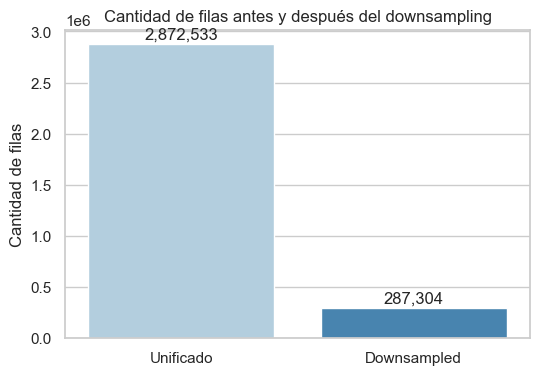

C:\Users\Usuario\AppData\Local\Temp\ipykernel_2164\1680644479.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_bruto['sujeto_id'].value_counts().index.astype(str),
C:\Users\Usuario\AppData\Local\Temp\ipykernel_2164\1680644479.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_ds['sujeto_id'].value_counts().index.astype(str),


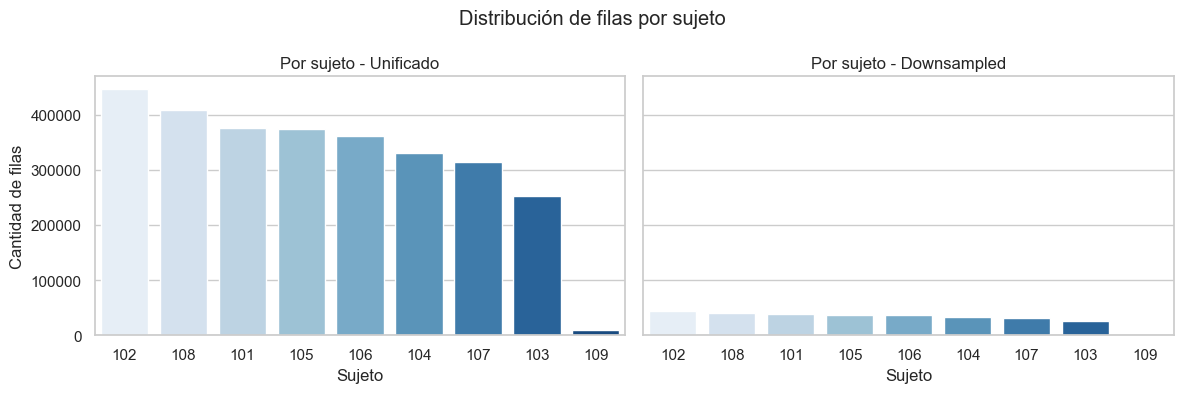

In [16]:
# Gráfico 1: Cantidad de filas antes y después del downsampling
fig, ax = plt.subplots(figsize=(6,4))
etapas = ['Unificado', 'Downsampled']
cantidades = [len(df_bruto), len(df_ds)]
sns.barplot(x=etapas, y=cantidades, ax=ax, palette='Blues')
ax.set_title('Cantidad de filas antes y después del downsampling')
ax.set_ylabel('Cantidad de filas')
for i, v in enumerate(cantidades):
    ax.text(i, v + max(cantidades)*0.01, f'{v:,}', ha='center', va='bottom')
plt.show()

# Gráfico 2: Distribución de filas por sujeto antes y después
fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)
sns.barplot(x=df_bruto['sujeto_id'].value_counts().index.astype(str),
            y=df_bruto['sujeto_id'].value_counts().values, ax=axes[0], palette='Blues')
axes[0].set_title('Por sujeto - Unificado')
axes[0].set_xlabel('Sujeto')
axes[0].set_ylabel('Cantidad de filas')
sns.barplot(x=df_ds['sujeto_id'].value_counts().index.astype(str),
            y=df_ds['sujeto_id'].value_counts().values, ax=axes[1], palette='Blues')
axes[1].set_title('Por sujeto - Downsampled')
axes[1].set_xlabel('Sujeto')
plt.suptitle('Distribución de filas por sujeto')
plt.tight_layout()
plt.show()

---
## Paso 3: Eliminación de columnas de orientación

Según la documentación oficial del dataset PAMAP2 (`readme.pdf`, UCI), las columnas de
orientación de los tres sensores IMU son **inválidas** en esta recolección. La calibración
de los quaterniones no fue completada correctamente durante la toma de datos.

Se eliminan las **12 columnas** de orientación (4 por IMU × 3 IMUs: hand, chest, ankle),
reduciendo el dataset de 55 → 43 columnas.

In [ ]:
print('Columnas eliminadas:')
for col in ORIENT_COLS:
    print(f'  - {col}')

df_sin_orient = df_ds.drop(columns=ORIENT_COLS)

print()
print(f'Columnas antes:   {df_ds.shape[1]}')
print(f'Columnas despues: {df_sin_orient.shape[1]}  (menos {df_ds.shape[1] - df_sin_orient.shape[1]})')
print(f'Shape resultante: {df_sin_orient.shape}')

---
## Paso 4: Exclusión de activityID == 0

El valor `activity_id = 0` está etiquetado como *"other"* en el dataset y corresponde a
**períodos transitorios** entre actividades. Estos registros:
- No representan ninguna actividad definida del protocolo
- Introducen ambigüedad en los patrones de señal
- Son ruido para el modelo de clasificación

Se excluyen completamente del dataset de trabajo.

In [ ]:
filas_antes = len(df_sin_orient)
df_excl = df_sin_orient[df_sin_orient['actividad_id'] != 0].copy()
filas_despues = len(df_excl)
eliminadas = filas_antes - filas_despues

print(f'Filas antes:                {filas_antes:>9,}')
print(f'Filas con actividad_id == 0: {eliminadas:>9,}  ({eliminadas/filas_antes*100:.1f}%)')
print(f'Filas despues:              {filas_despues:>9,}')
print()
acts = sorted(df_excl['actividad_id'].unique())
n_acts = df_excl['actividad_id'].nunique()
print(f'Actividades presentes ({n_acts}): {acts}')

---
## Paso 5: Tratamiento de NaNs en heart_rate

El sensor de frecuencia cardíaca (BM-CS5X) muestrea a **~9 Hz**, mientras que las IMUs
muestrean a 100 Hz. Esto genera **NaN frecuentes y estructurales** en `heart_rate`:
no son errores de medición sino una consecuencia directa de la diferencia de frecuencias.

**Estrategia: interpolación lineal por sujeto + fill en bordes**

- No se usa media/mediana global: incorrecto para una serie temporal fisiológica continua
- Se interpola linealmente dentro de cada `subject_id` para respetar la continuidad temporal
- Los NaN en bordes (inicio/fin de sesión) se resuelven con forward-fill y backward-fill
- El `groupby` por sujeto garantiza que no se mezclen señales entre participantes

In [ ]:
nan_antes = df_excl['frecuencia_cardiaca'].isna().sum()
pct_antes = nan_antes / len(df_excl) * 100
print(f'NaNs en frecuencia_cardiaca ANTES:   {nan_antes:,}  ({pct_antes:.1f}%)')

df_limpio = df_excl.copy()
df_limpio['frecuencia_cardiaca'] = (
    df_limpio.groupby('sujeto_id')['frecuencia_cardiaca']
            .transform(lambda x: x.interpolate(method='linear').ffill().bfill())
)

nan_despues = df_limpio['frecuencia_cardiaca'].isna().sum()
print(f'NaNs en frecuencia_cardiaca DESPUES: {nan_despues:,}')
print(f'NaNs resueltos:             {nan_antes - nan_despues:,}')

---
## Verificación final del dataset limpio

Se verifica el estado del DataFrame resultante: shape, tipos de datos y porcentaje
de nulos por columna. El dataset debe tener **0 nulos** antes de ser guardado.

In [ ]:
print('=' * 60)
print('VERIFICACION FINAL DEL DATASET LIMPIO')
print('=' * 60)

print(f'Shape: {df_limpio.shape[0]:,} filas x {df_limpio.shape[1]} columnas')

n_acts = df_limpio['actividad_id'].nunique()
print(f'Actividades presentes ({n_acts}):')
print(' ', sorted(df_limpio['actividad_id'].unique()))

n_subjs = df_limpio['sujeto_id'].nunique()
print(f'Sujetos ({n_subjs}):')
print(' ', sorted(df_limpio['sujeto_id'].unique()))

print()
print('DTYPES:')
print(df_limpio.dtypes.to_string())

print()
pct_nulos = df_limpio.isnull().mean() * 100
nulos_nonzero = pct_nulos[pct_nulos > 0]
if len(nulos_nonzero) > 0:
    print('% NULOS POR COLUMNA (solo columnas con nulos):')
    print(nulos_nonzero.sort_values(ascending=False).to_string())
else:
    print('Sin valores nulos en el dataset final.')

print()
print('ESTADISTICOS DESCRIPTIVOS:')
display(df_limpio.describe().round(4))

In [ ]:
output_file = OUTPUT_PATH / 'pamap2_limpio.csv'
df_limpio.to_csv(output_file, index=False)
print(f'Dataset guardado en: {output_file}')
print(f'Shape final:         {df_limpio.shape}')
print()
print(f'Columnas ({df_limpio.shape[1]}):')
for col in df_limpio.columns:
    print(f'  {col}')